# Digital Payments in India: A Data-Driven Analysis (2016–2025)

**Student:** Anchal Kaushal  
**Program:** IBM SkillsBuild Data Analytics with AI Internship

This project studies the growth of digital payments in India using an illustrative learning dataset covering UPI, IMPS and card payments from 2016 to 2025.

**Data note:** The 30-row dataset in this notebook is an illustrative dataset created for learning and demonstration. It is not presented as an official extract from NPCI, RBI or another statistical database.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 1. Creating the project dataset

In [2]:
years = list(range(2016, 2026))

payment_data = {
    'UPI': {
        'transactions': [0.1, 0.9, 5.3, 10.8, 12.5, 38.7, 74.0, 83.2, 90.4, 102.5],
        'value': [0.01, 0.07, 0.4, 0.8, 1.0, 2.0, 4.5, 7.8, 11.2, 15.0]
    },
    'IMPS': {
        'transactions': [2.0, 2.4, 2.8, 3.2, 3.5, 3.8, 4.1, 4.4, 4.8, 5.1],
        'value': [1.6, 2.0, 2.5, 3.0, 3.5, 4.2, 5.0, 5.8, 6.7, 7.6]
    },
    'Cards': {
        'transactions': [10.0, 11.2, 12.5, 13.7, 14.8, 16.0, 18.0, 20.2, 22.5, 25.0],
        'value': [4.8, 5.3, 5.9, 6.5, 7.2, 8.0, 9.2, 10.5, 12.0, 13.8]
    }
}

internet_penetration = [34, 36, 40, 42, 48, 54, 58, 62, 67, 70]
smartphone_penetration = [24, 28, 33, 38, 44, 50, 56, 62, 68, 73]

rows = []
for method, values in payment_data.items():
    for i, year in enumerate(years):
        rows.append({
            'Year': year,
            'Payment_Method': method,
            'Transactions_Million': values['transactions'][i],
            'Transaction_Value_Lakh_Crore': values['value'][i],
            'Internet_Penetration_Percent': internet_penetration[i],
            'Smartphone_Penetration_Percent': smartphone_penetration[i]
        })

df = pd.DataFrame(rows)
df.head()


,Year,Payment_Method,Transactions_Million,Transaction_Value_Lakh_Crore,Internet_Penetration_Percent,Smartphone_Penetration_Percent
0,2016,UPI,0.1,0.01,34,24
1,2017,UPI,0.9,0.07,36,28
2,2018,UPI,5.3,0.40,40,33
3,2019,UPI,10.8,0.80,42,38
4,2020,UPI,12.5,1.00,48,44


## 2. Basic data checks

I check the shape, missing values, duplicate rows and payment-method names before analysis.

In [3]:
print('Rows and columns:', df.shape)
print('\nMissing values:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nPayment methods:', df['Payment_Method'].unique())


Rows and columns: (30, 6)

Missing values:
Year                              0
Payment_Method                    0
Transactions_Million              0
Transaction_Value_Lakh_Crore      0
Internet_Penetration_Percent      0
Smartphone_Penetration_Percent    0
dtype: int64

Duplicate rows: 0

Payment methods: ['UPI' 'IMPS' 'Cards']


## 3. Growth in digital-payment transactions

Total digital-payment transactions increased about 11.0 times from 2016 to 2025.


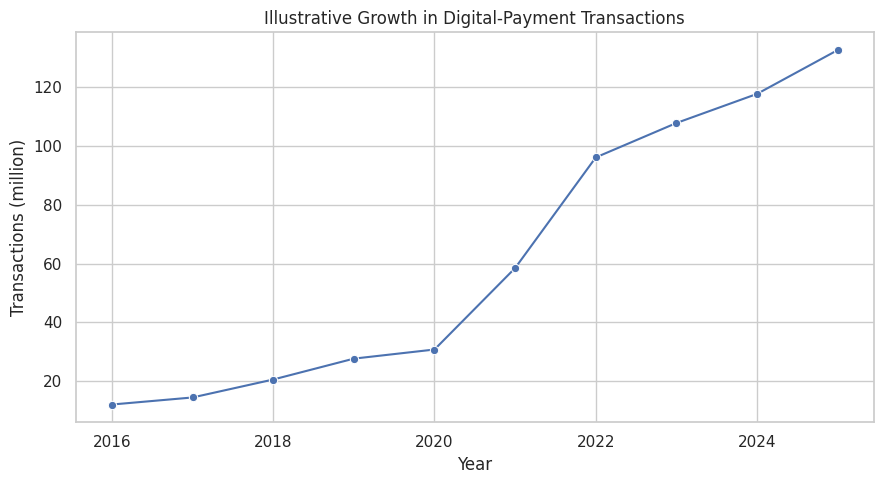

In [4]:
yearly = df.groupby('Year', as_index=False)['Transactions_Million'].sum()
growth_multiple = yearly.iloc[-1, 1] / yearly.iloc[0, 1]
print(f'Total digital-payment transactions increased about {growth_multiple:.1f} times from 2016 to 2025.')

plt.figure(figsize=(9,5))
sns.lineplot(data=yearly, x='Year', y='Transactions_Million', marker='o')
plt.title('Illustrative Growth in Digital-Payment Transactions')
plt.xlabel('Year')
plt.ylabel('Transactions (million)')
plt.tight_layout()
plt.show()


### Observation

The constructed dataset shows strong growth in total digital-payment transactions between 2016 and 2025. The sharpest increase is associated with the rapid expansion of UPI transactions.

## 4. Payment-method comparison

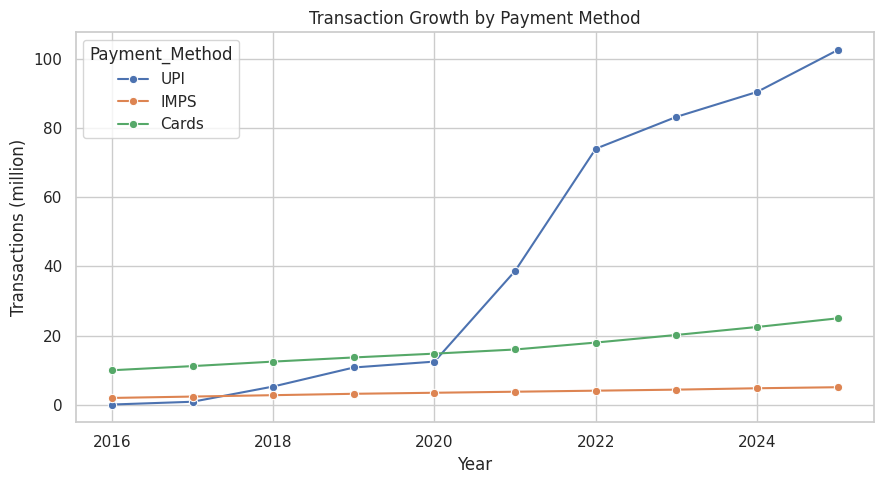

,Payment_Method,Transactions_Million,Transaction_Value_Lakh_Crore
9,UPI,102.5,15.0
29,Cards,25.0,13.8
19,IMPS,5.1,7.6


In [5]:
plt.figure(figsize=(9,5))
sns.lineplot(data=df, x='Year', y='Transactions_Million', hue='Payment_Method', marker='o')
plt.title('Transaction Growth by Payment Method')
plt.xlabel('Year')
plt.ylabel('Transactions (million)')
plt.tight_layout()
plt.show()

latest = df[df['Year'] == 2025][[
    'Payment_Method', 'Transactions_Million', 'Transaction_Value_Lakh_Crore'
]]
latest.sort_values('Transactions_Million', ascending=False)


In the 2025 observations, UPI has the highest transaction volume. This comparison is limited to the illustrative project dataset and should not be treated as an official market ranking.

## 5. Transactions and transaction value

Pearson correlation: 0.549


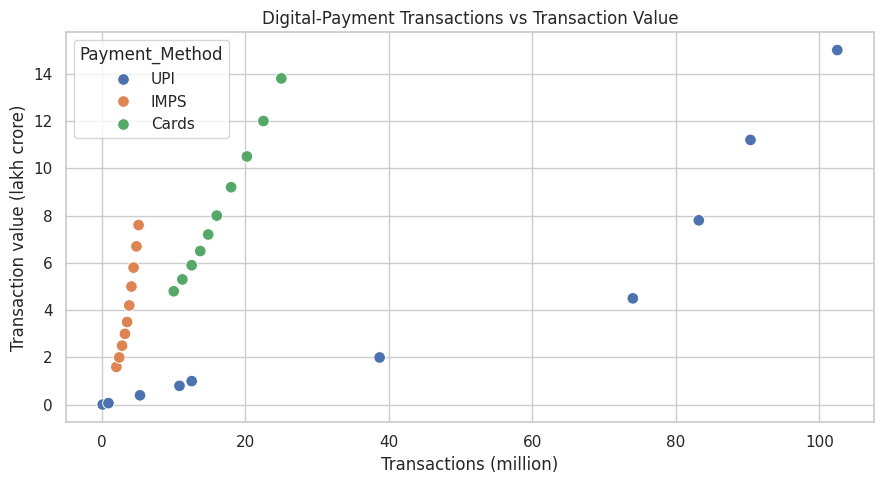

In [6]:
correlation = df['Transactions_Million'].corr(df['Transaction_Value_Lakh_Crore'])
print(f'Pearson correlation: {correlation:.3f}')

plt.figure(figsize=(9,5))
sns.scatterplot(
    data=df,
    x='Transactions_Million',
    y='Transaction_Value_Lakh_Crore',
    hue='Payment_Method',
    s=70
)
plt.title('Digital-Payment Transactions vs Transaction Value')
plt.xlabel('Transactions (million)')
plt.ylabel('Transaction value (lakh crore)')
plt.tight_layout()
plt.show()


The relationship between transaction count and transaction value is positive in this constructed dataset. Correlation alone does not establish causation, because payment mix, transaction size, economic conditions and other factors can influence both measures.

## 6. Smartphone penetration and payment activity

Correlation between smartphone penetration and transaction volume: 0.522


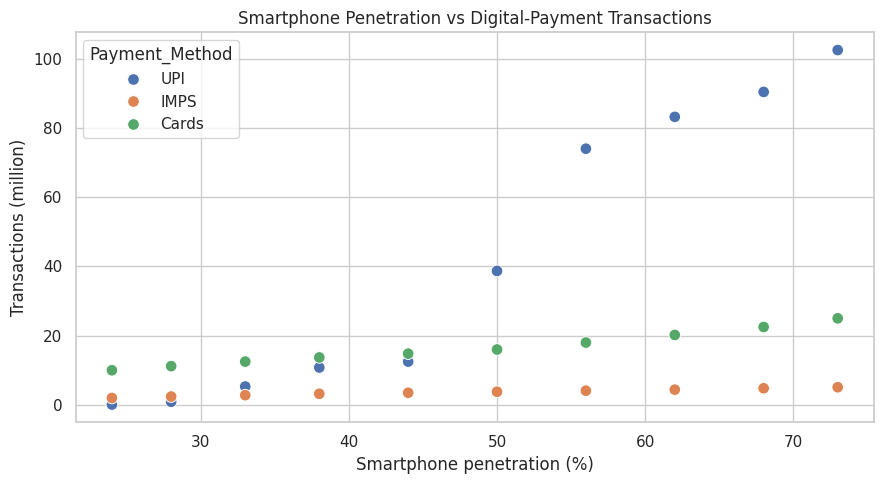

In [7]:
smartphone_corr = df['Smartphone_Penetration_Percent'].corr(df['Transactions_Million'])
print(f'Correlation between smartphone penetration and transaction volume: {smartphone_corr:.3f}')

plt.figure(figsize=(9,5))
sns.scatterplot(
    data=df,
    x='Smartphone_Penetration_Percent',
    y='Transactions_Million',
    hue='Payment_Method',
    s=70
)
plt.title('Smartphone Penetration vs Digital-Payment Transactions')
plt.xlabel('Smartphone penetration (%)')
plt.ylabel('Transactions (million)')
plt.tight_layout()
plt.show()


## 7. Machine-learning model

A Random Forest regression model estimates transaction value from transaction volume and smartphone penetration. A train/test split is used so the test score is separate from the observations used for training.

In [8]:
X = df[['Transactions_Million', 'Smartphone_Penetration_Percent']]
y = df['Transaction_Value_Lakh_Crore']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5

print(f'Test R²: {r2:.3f}')
print(f'Test MAE: {mae:.3f} lakh crore')
print(f'Test RMSE: {rmse:.3f} lakh crore')


Test R²: 0.736
Test MAE: 1.399 lakh crore
Test RMSE: 1.904 lakh crore


The model is included as a learning exercise. Its performance depends on the small illustrative dataset and should not be interpreted as a real-world forecasting guarantee.

In [9]:
scenario = pd.DataFrame({
    'Transactions_Million': [150],
    'Smartphone_Penetration_Percent': [85]
})
prediction = model.predict(scenario)[0]
print(f'Illustrative scenario estimate: {prediction:.2f} lakh crore')


Illustrative scenario estimate: 10.98 lakh crore


## 8. What the analysis tells us

- Digital-payment activity increases strongly across the period covered by the project dataset.
- UPI shows the fastest transaction-volume growth among the three payment methods in the constructed data.
- Transaction count and transaction value have a positive association in the dataset.
- Smartphone penetration and transaction volume also move positively together in the constructed observations.
- A train/test Random Forest model demonstrates how machine learning can be added to a basic analytics workflow.

## 9. Limitations

The dataset is small and illustrative. It is not an official statistical series and should not be used for financial, policy or investment forecasts. The three payment methods are broad categories, and the analysis does not capture transaction-size differences, fees, merchant acceptance, income, regional variation or other factors.

## 10. Future Scope

A stronger version could use directly downloaded NPCI/RBI datasets, retain source references for every important metric, add monthly observations, compare states or user segments, test time-series models, and build an interactive Power BI or Tableau dashboard.

## Conclusion

Digital payments have become an important part of the data-driven transformation of financial activity. This project demonstrates a complete beginner-friendly workflow: creating and checking a dataset, visualizing trends, measuring relationships and applying a machine-learning model. The main learning is that useful analysis depends not only on the model but also on data quality, clear definitions and honest interpretation.
